# Yelp Pipeline - 03: NLP, Sentiment Classification e Topic Modeling con LDA

Questo notebook implementa l'intera pipeline di elaborazione del linguaggio naturale e text mining:
1. **Preprocessing Testuale e Normalizzazione**: Pulizia regex, rimozione stopword e conversione dei punteggi in stelle in classi di sentiment (Positivo vs Negativo).
2. **Word Clouds e Top Parole**: Visualizzazione dei termini più frequenti per recensioni positive e negative.
3. **Analisi dei Bigrammi e Grafo di Co-occorrenza dei Termini**: Visualizzazione a grafo (NetworkX) delle relazioni tra parole (es. abbinamenti cibo-servizio).
4. **Topic Modeling Non Supervisionato (LDA)**: Estrazione automatica dei macro-temi di recensione per isolare specifici motivi di reclamo (es. tempi di attesa, scortesia del personale, prezzi) rispetto ai punti di forza.
5. **Classificazione Supervisionata del Sentiment**: Confronto tra **Logistic Regression** e **Multinomial Naive Bayes** su split Train/Val/Test (70/15/15) con TF-IDF (10.000 feature) e matrici di confusione.
6. **Case Study su Ristoranti Celebri**: Analisi temporale del sentiment e dei feedback per locali storici (*Mon Ami Gabi*, *The Wicked Spoon*, *Pai Northern Thai Kitchen*).

## Configurazione Ambiente

In [1]:
%pip install -q scikit-learn nltk joblib wordcloud loguru seaborn matplotlib networkx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 699.1 kB/s eta 0:00:00


## Montaggio Google Drive e Configurazione

In [2]:
import os
import sys
import json
import time
import re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from loguru import logger
import joblib
from wordcloud import WordCloud
import networkx as nx

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score, precision_score, recall_score

os.environ['TZ'] = 'Europe/Rome'
time.tzset()

logger.remove()
logger.add(
    sys.stdout,
    colorize=True,
    format="<green>{time:YYYY-MM-DD HH:mm:ss}</green> | <level>{level: <8}</level> | <cyan>{message}</cyan>"
)

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.dpi'] = 120

try:
    from google.colab import drive
    drive.mount('/content/drive')
    DRIVE_DIR = Path('/content/drive/MyDrive/yelp_data')
except Exception:
    DRIVE_DIR = Path('./yelp_data')

DRIVE_DIR.mkdir(parents=True, exist_ok=True)
logger.info(f"Directory artifact: {DRIVE_DIR}")

Mounted at /content/drive
2026-10-04 16:54:07 | INFO     | Directory artifact: /content/drive/MyDrive/yelp_data


## Caricamento Recensioni

In [3]:
required_parquets = ['yelp_reviews.parquet', 'yelp_businesses.parquet']
missing = [f for f in required_parquets if not (DRIVE_DIR / f).exists()]
if missing:
    raise FileNotFoundError(
        f"Artifact mancanti su Drive: {missing}. Esegui prima Yelp_01_Ingestion_Preprocessing.ipynb!"
    )

import polars as pl
t0 = time.perf_counter()
df_reviews = pl.read_parquet(DRIVE_DIR / 'yelp_reviews.parquet')
df_businesses = pl.read_parquet(DRIVE_DIR / 'yelp_businesses.parquet')

elapsed = time.perf_counter() - t0
logger.success(f"Caricamento completato in {elapsed:.2f}s")

2026-10-04 16:54:38 | SUCCESS  | Caricamento completato in 30.35s


## 1. Preprocessing Testuale e Sentiment Labeling

In [4]:
def clean_text_simple(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'<.*?>', ' ', text)
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()

# Operazioni di filtro e manipolazione veloci in Polars
df_nlp = df_reviews.filter(pl.col('stars') != 3.0).with_columns(
    (pl.col('stars') >= 4.0).cast(pl.Int32).alias('sentiment')
)

SAMPLE_LIMIT = min(df_nlp.height, 60000)
if df_nlp.height > SAMPLE_LIMIT:
    df_nlp = df_nlp.sample(n=SAMPLE_LIMIT, seed=42)

t0 = time.perf_counter()

df_nlp = df_nlp.with_columns(
    pl.col('text').map_elements(clean_text_simple, return_dtype=pl.Utf8).alias('clean_text')
)

df_nlp = df_nlp.filter(pl.col('clean_text').str.len_chars() > 10)

pos_count = df_nlp.filter(pl.col('sentiment') == 1).height
neg_count = df_nlp.filter(pl.col('sentiment') == 0).height

logger.info(f"Testo pulito in {time.perf_counter() - t0:.2f}s | Campione finale: {df_nlp.height:,d} (Positivi: {pos_count:,d}, Negativi: {neg_count:,d})")

df_nlp = df_nlp.to_pandas()

2026-10-04 16:54:41 | INFO     | Testo pulito in 2.89s | Campione finale: 59,996 (Positivi: 46,647, Negativi: 13,349)


## 2. Word Clouds: Recensioni Positive vs Negative

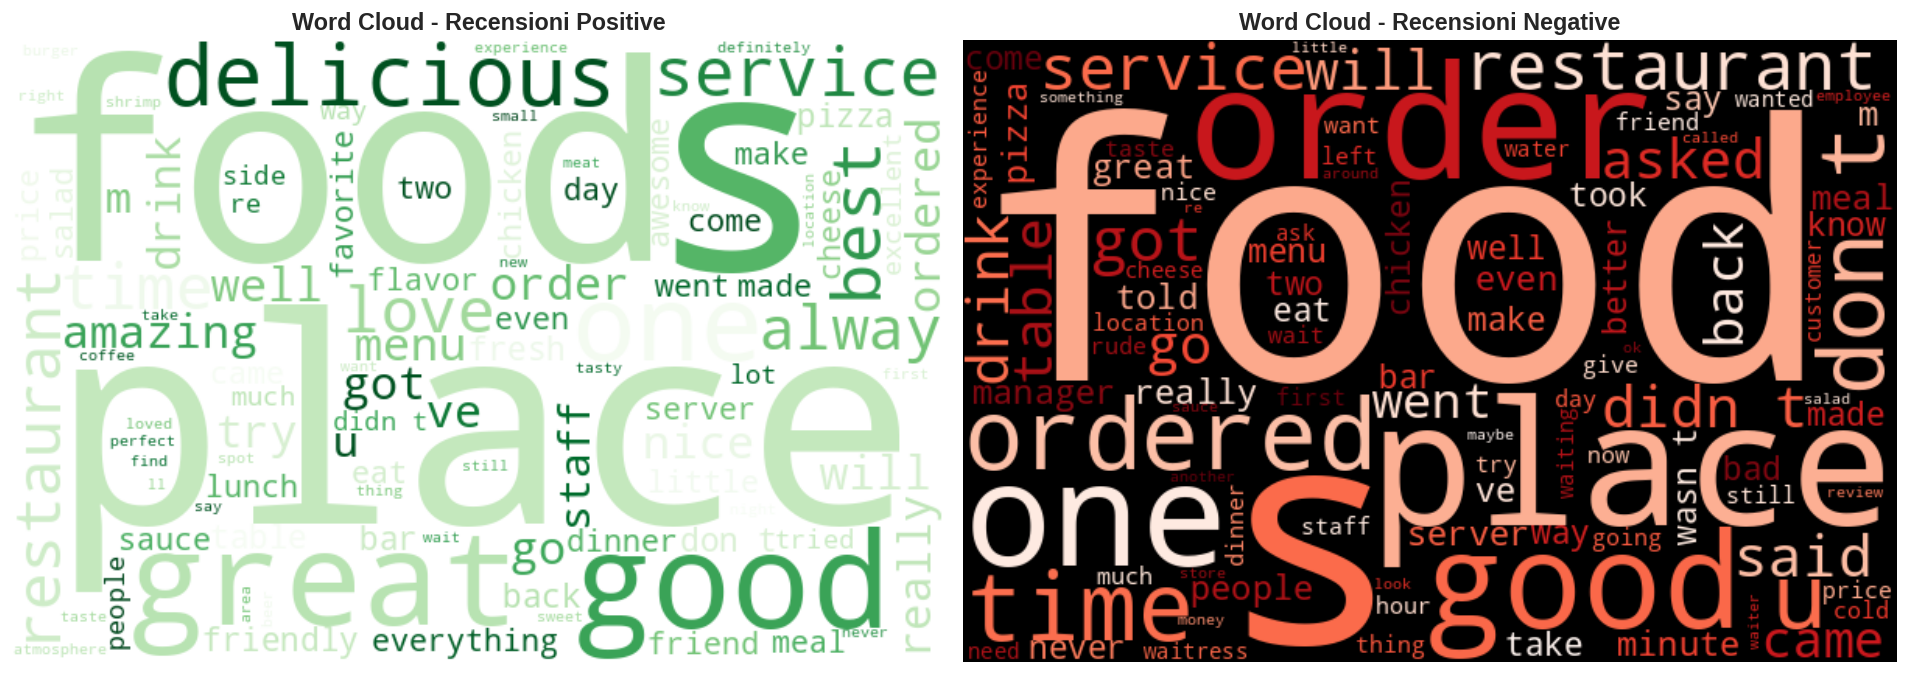

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

pos_text = " ".join(df_nlp[df_nlp['sentiment'] == 1]['clean_text'].head(3000))
neg_text = " ".join(df_nlp[df_nlp['sentiment'] == 0]['clean_text'].head(3000))

wc_pos = WordCloud(width=600, height=400, background_color='white', colormap='Greens', max_words=100).generate(pos_text)
wc_neg = WordCloud(width=600, height=400, background_color='black', colormap='Reds', max_words=100).generate(neg_text)

axes[0].imshow(wc_pos, interpolation='bilinear')
axes[0].set_title("Word Cloud - Recensioni Positive", fontsize=14, weight='bold')
axes[0].axis('off')

axes[1].imshow(wc_neg, interpolation='bilinear')
axes[1].set_title("Word Cloud - Recensioni Negative", fontsize=14, weight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()

## 3. Bigrammi e Grafo di Co-occorrenza dei Termini

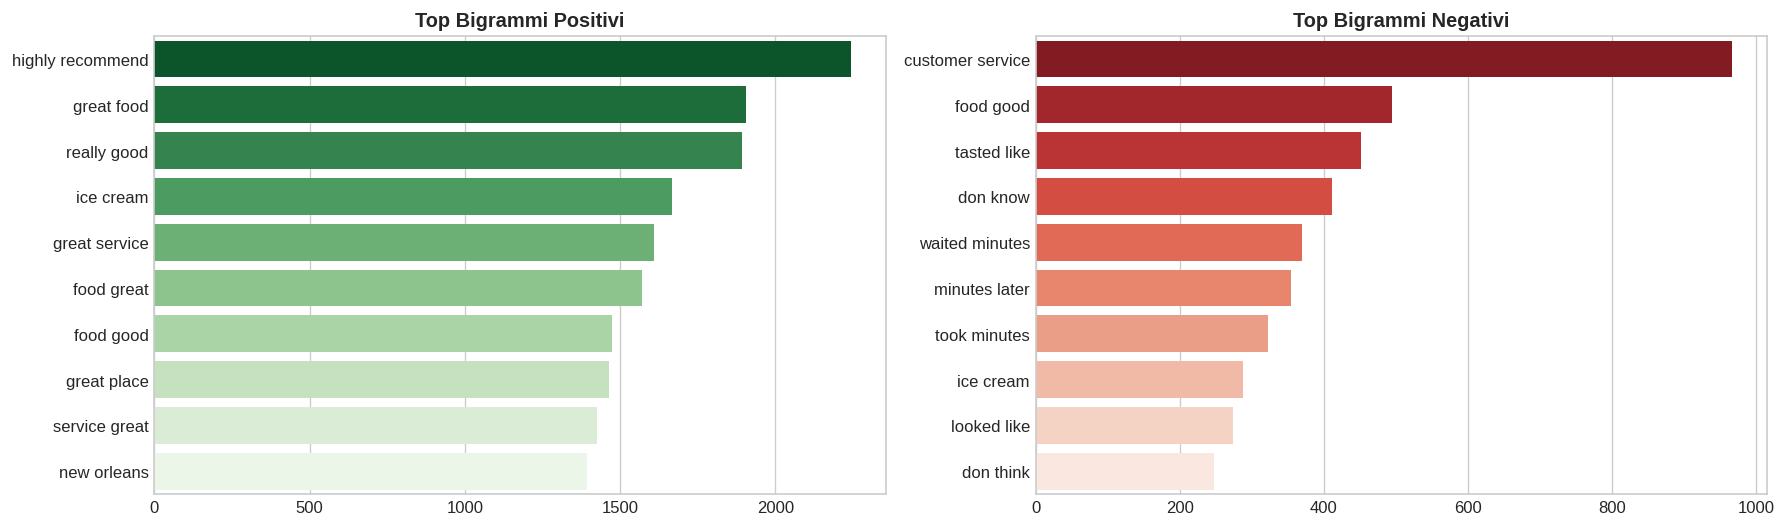

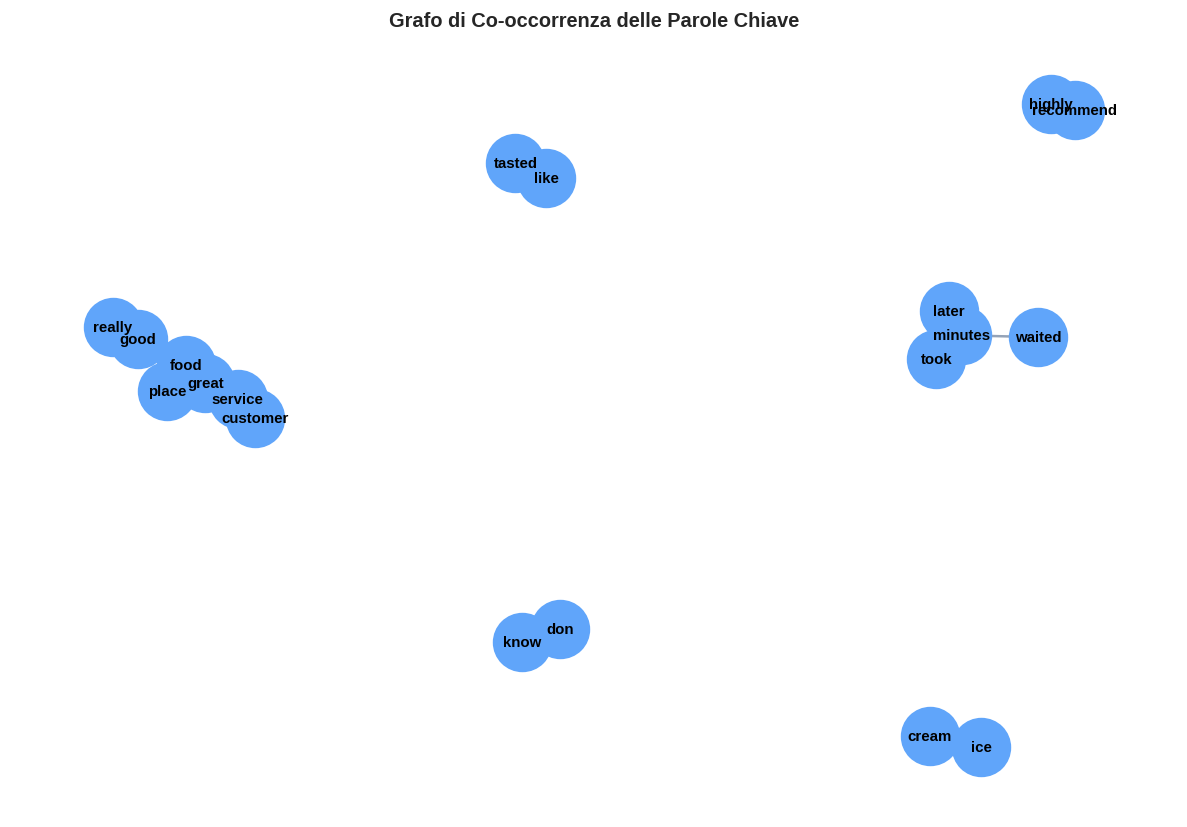

In [6]:
def get_top_bigrams(corpus, top_n=12):
    vec = CountVectorizer(ngram_range=(2, 2), stop_words='english', max_features=5000)
    counts = vec.fit_transform(corpus).sum(axis=0)
    features = vec.get_feature_names_out()
    freqs = np.asarray(counts).flatten()
    sorted_idx = freqs.argsort()[::-1][:top_n]
    return [(features[i], freqs[i]) for i in sorted_idx]

top_pos_bg = get_top_bigrams(df_nlp[df_nlp['sentiment'] == 1]['clean_text'], 10)
top_neg_bg = get_top_bigrams(df_nlp[df_nlp['sentiment'] == 0]['clean_text'], 10)

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))

p_words, p_vals = zip(*top_pos_bg)
sns.barplot(x=list(p_vals), y=list(p_words), ax=axes[0], palette='Greens_r', hue=list(p_words), legend=False)
axes[0].set_title("Top Bigrammi Positivi", weight='bold')

n_words, n_vals = zip(*top_neg_bg)
sns.barplot(x=list(n_vals), y=list(n_words), ax=axes[1], palette='Reds_r', hue=list(n_words), legend=False)
axes[1].set_title("Top Bigrammi Negativi", weight='bold')

plt.tight_layout()
plt.show()

#grafo di co-occorrenza dei termini (NetworkX)
G_words = nx.Graph()
for bg, weight in (top_pos_bg[:8] + top_neg_bg[:8]):
    w1, w2 = bg.split()
    G_words.add_edge(w1, w2, weight=weight)

plt.figure(figsize=(10, 7))
pos_w = nx.spring_layout(G_words, seed=42, k=0.5)
nx.draw_networkx(G_words, pos_w, node_color='#60a5fa', node_size=1200, font_size=9, font_weight='bold', edge_color='#94a3b8', width=1.5)
plt.title("Grafo di Co-occorrenza delle Parole Chiave", weight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

## 4. Topic Modeling Non Supervisionato con LDA

In [7]:
count_vec = CountVectorizer(
    max_df=0.85,
    min_df=10,
    max_features=5000,
    stop_words='english',
    ngram_range=(1, 2)
)
tf_matrix = count_vec.fit_transform(df_nlp['clean_text'])

NUM_TOPICS = 5
lda = LatentDirichletAllocation(
    n_components=NUM_TOPICS,
    random_state=42,
    max_iter=10,
    learning_method='online',
    n_jobs=-1
)
lda.fit(tf_matrix)

feature_names = count_vec.get_feature_names_out()
topic_rows = []

for topic_idx, topic in enumerate(lda.components_):
    top_words = [feature_names[i] for i in topic.argsort()[::-1][:8]]
    topic_rows.append({
        'Topic ID': topic_idx + 1,
        'Parole Chiave': ", ".join(top_words)
    })

topics_df = pd.DataFrame(topic_rows)
topics_df.to_csv(DRIVE_DIR / 'topics_summary.csv', index=False)
display(topics_df)

,Topic ID,Parole Chiave
0,1,"place, like, ve, don, food, just, good, time"
1,2,"great, food, service, place, good, friendly, a..."
2,3,"pizza, coffee, good, breakfast, delicious, cre..."
3,4,"chicken, good, ordered, sauce, salad, cheese, ..."
4,5,"food, order, time, service, just, didn, minute..."


## 5. Classificazione Supervisionata del Sentiment

2026-10-04 16:57:15 | SUCCESS  | Logistic Regression | F1: 0.9696 | AUC: 0.9862 | Fit: 0.38s | Inferenza: 0.003s
2026-10-04 16:57:15 | SUCCESS  | Multinomial NB      | F1: 0.9584 | AUC: 0.9780 | Fit: 0.02s | Inferenza: 0.010s


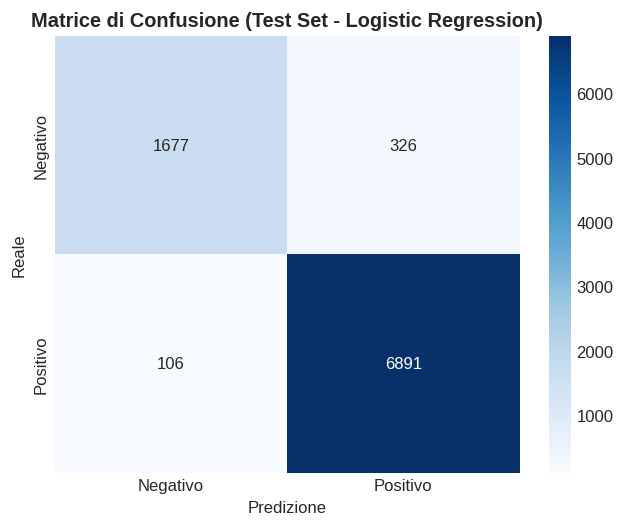

In [8]:
X_train, X_temp, y_train, y_temp = train_test_split(
    df_nlp['clean_text'], df_nlp['sentiment'],
    test_size=0.30, random_state=42, stratify=df_nlp['sentiment']
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50, random_state=42, stratify=y_temp
)

tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1, 2), stop_words='english', sublinear_tf=True)
X_train_vec = tfidf.fit_transform(X_train)
X_val_vec = tfidf.transform(X_val)
X_test_vec = tfidf.transform(X_test)

# Logistic Regression
t0 = time.perf_counter()
lr = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
lr.fit(X_train_vec, y_train)
t_lr_train = time.perf_counter() - t0

t0 = time.perf_counter()
y_pred_lr = lr.predict(X_test_vec)
y_prob_lr = lr.predict_proba(X_test_vec)[:, 1]
t_lr_inf = time.perf_counter() - t0

# Naive Bayes
t0 = time.perf_counter()
nb = MultinomialNB(alpha=0.5)
nb.fit(X_train_vec, y_train)
t_nb_train = time.perf_counter() - t0

t0 = time.perf_counter()
y_pred_nb = nb.predict(X_test_vec)
y_prob_nb = nb.predict_proba(X_test_vec)[:, 1]
t_nb_inf = time.perf_counter() - t0

f1_lr = f1_score(y_test, y_pred_lr)
f1_nb = f1_score(y_test, y_pred_nb)
auc_lr = roc_auc_score(y_test, y_prob_lr)
auc_nb = roc_auc_score(y_test, y_prob_nb)

logger.success(f"Logistic Regression | F1: {f1_lr:.4f} | AUC: {auc_lr:.4f} | Fit: {t_lr_train:.2f}s | Inferenza: {t_lr_inf:.3f}s")
logger.success(f"Multinomial NB      | F1: {f1_nb:.4f} | AUC: {auc_nb:.4f} | Fit: {t_nb_train:.2f}s | Inferenza: {t_nb_inf:.3f}s")

# Matrice di confusione Logistic Regression
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negativo', 'Positivo'], yticklabels=['Negativo', 'Positivo'])
plt.title("Matrice di Confusione (Test Set - Logistic Regression)", weight='bold')
plt.xlabel("Predizione")
plt.ylabel("Reale")
plt.tight_layout()
plt.show()

## 6. Case Study su Ristoranti Celebri: Analisi Temporale

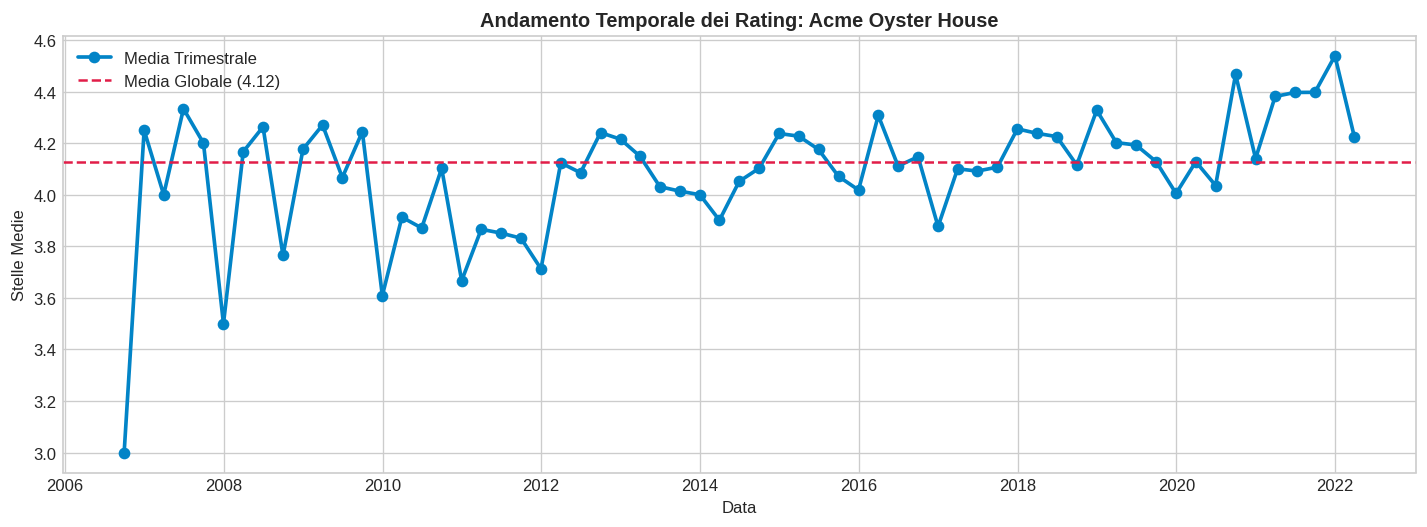

In [9]:
# Selezione di un ristorante ad alto volume (es. Mon Ami Gabi o The Wicked Spoon)
popular_names = ['Mon Ami Gabi', 'Wicked Spoon', 'Pai Northern Thai Kitchen']
pattern = '(?i)' + '|'.join(popular_names)
target_b = df_businesses.filter(pl.col('name').str.contains(pattern))

if target_b.height > 0:
    selected_bid = target_b[0, 'business_id']
    selected_name = target_b[0, 'name']
else:
    top_b = df_businesses.sort('review_count', descending=True).head(1)
    selected_bid = top_b[0, 'business_id']
    selected_name = top_b[0, 'name']

# Filtriamo in Polars per massima velocità e convertiamo in Pandas per il resampling temporale
rest_revs = df_reviews.filter(pl.col('business_id') == selected_bid).to_pandas()
rest_revs['date'] = pd.to_datetime(rest_revs['date'])
rest_revs = rest_revs.sort_values('date').set_index('date')

quarterly = rest_revs['stars'].resample('QE').mean().dropna()

if len(quarterly) > 2:
    plt.figure(figsize=(12, 4.5))
    plt.plot(quarterly.index, quarterly.values, marker='o', color='#0284c7', linewidth=2.2, label='Media Trimestrale')
    plt.axhline(rest_revs['stars'].mean(), color='#e11d48', linestyle='--', label=f"Media Globale ({rest_revs['stars'].mean():.2f})")
    plt.title(f"Andamento Temporale dei Rating: {selected_name}", weight='bold')
    plt.xlabel("Data")
    plt.ylabel("Stelle Medie")
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    logger.info("Dati temporali non sufficienti per il plot trimestrale.")

## 7. Salvataggio Modelli e Metriche

In [10]:
joblib.dump(lr, DRIVE_DIR / 'sentiment_model.joblib')
joblib.dump(tfidf, DRIVE_DIR / 'tfidf_vectorizer.joblib')

sentiment_metrics = {
    'model_name': 'Logistic Regression (TF-IDF)',
    'f1_score': float(f1_lr),
    'roc_auc': float(auc_lr),
    'precision': float(precision_score(y_test, y_pred_lr)),
    'recall': float(recall_score(y_test, y_pred_lr)),
    'train_time_s': float(t_lr_train),
    'inference_time_s': float(t_lr_inf),
    'num_topics': int(NUM_TOPICS),
    'test_samples': int(len(y_test))
}

with open(DRIVE_DIR / 'sentiment_metrics.json', 'w', encoding='utf-8') as f:
    json.dump(sentiment_metrics, f, indent=2)

logger.success("Modello di sentiment e metriche salvati su Google Drive.")

2026-10-04 16:57:19 | SUCCESS  | Modello di sentiment e metriche salvati su Google Drive.
